| Company        | Ticker |
| -------------- | ------ |
| Microsoft      | MSFT   |
| Apple          | AAPL   |
| Amazon         | AMZN   |
| Tesla, Inc.    | TSLA   |
| NVIDIA         | NVDA   |

### India Stocks
| Company                   | Ticker      |
| ------------------------- | ----------- |
| Reliance Industries       | RELIANCE.NS |
| Tata Consultancy Services | TCS.NS      |
| Infosys                   | INFY.NS     |
| HDFC Bank                 | HDFCBANK.NS |
    
### Indices
| Index                        | Ticker |
| ---------------------------- | ------ |
| S&P 500                      | ^GSPC  |
| NIFTY 50                     | ^NSEI  |


In [134]:
import yfinance as yf

data = yf.download("MSFT", start="1986-01-01")

# print(data)

data.to_csv("msft.csv")

[*********************100%***********************]  1 of 1 completed


In [135]:
df = pd.read_csv('msft.csv')

In [136]:
df = df.dropna()
df = df.drop_duplicates()

In [137]:
# reset index so Date becomes a column
df = df.drop(0)   # removes row with index 0,1
df = df.reset_index(drop=True)
df = df.rename(columns={"Price": "date",})
# rename columns

df.head()

,date,Close,High,Low,Open,Volume
0,1986-03-13,0.05925336480140686,0.061899049792752264,0.053963211770512415,0.053963211770512415,1031788800
1,1986-03-14,0.06136944890022278,0.062428088377097395,0.05925338689872373,0.05925338689872373,308160000
2,1986-03-17,0.06242808699607849,0.06295710248475049,0.06136944754262283,0.06136944754262283,133171200
3,1986-03-18,0.060840461403131485,0.0629571328550045,0.06031144565926452,0.062428117111137535,67766400
4,1986-03-19,0.059782419353723526,0.0613694663049431,0.059253403703317,0.060840450654536575,47894400


In [138]:
df.dtypes

date      str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [139]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

In [140]:
df['date'] = df['date'].apply(str_to_datetime)

In [141]:
df.index = df.pop('date')
df

,Close,High,Low,Open,Volume
date,,,,,
1986-03-13,0.05925336480140686,0.061899049792752264,0.053963211770512415,0.053963211770512415,1031788800
1986-03-14,0.06136944890022278,0.062428088377097395,0.05925338689872373,0.05925338689872373,308160000
1986-03-17,0.06242808699607849,0.06295710248475049,0.06136944754262283,0.06136944754262283,133171200
1986-03-18,0.060840461403131485,0.0629571328550045,0.06031144565926452,0.062428117111137535,67766400
1986-03-19,0.059782419353723526,0.0613694663049431,0.059253403703317,0.060840450654536575,47894400
...,...,...,...,...,...
2026-04-13,384.3699951171875,384.5400085449219,371.0199890136719,373.6099853515625,35745800
2026-04-14,393.1099853515625,394.69000244140625,386.5199890136719,387.9200134277344,37504500
2026-04-15,411.2200012207031,414.3699951171875,396.7300109863281,398.0,45063400


In [142]:
# cols = df.columns.drop(["sentiment_mean","sentiment_3d","sentiment_7d","sentiment_14d"])
cols = df.columns

In [143]:
from sklearn.preprocessing import MinMaxScaler

X_scaler = MinMaxScaler()
Y_scaler = MinMaxScaler()
temp = df[['Close']]

df[cols]= X_scaler.fit_transform(df[cols])

df[['Close']] = Y_scaler.fit_transform(temp)

In [144]:
df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object

In [145]:
import joblib

joblib.dump(X_scaler, "X_scaler.pkl")
joblib.dump(Y_scaler, "Y_scaler.pkl")

['Y_scaler.pkl']

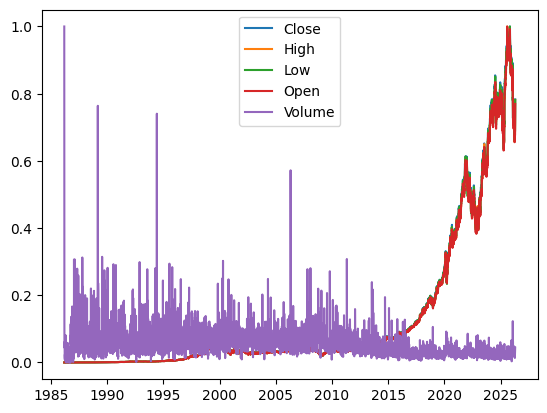

In [146]:
import matplotlib.pyplot as plt
for col in cols:
    plt.plot(df.index, df[col],label = col)

plt.legend()
plt.show()

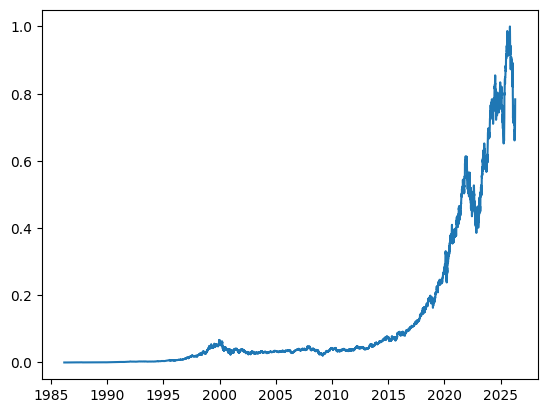

In [147]:
plt.plot(df.index, df["Close"])

##  Visual Example

### Dataset
```
Mar 22
Mar 23
Mar 24
Mar 25
Mar 26
Mar 29 ← next trading day
```

### For `n = 3`

Input: `[Mar22, Mar23, Mar24]`  
Target: `Mar25`

### Next iteration : find the next days in 7 days range in Mar 25 -> 25,26,29,.....

Input: `[Mar23, Mar24, Mar25]`  
Target: `Mar26`

### Next iteration : find the next days in 7 days range in Mar 26 -> 26,29,.....

Input: `[Mar24, Mar25, Mar26]`  
Target: `Mar29`


In [148]:
# feature_cols = cols.tolist()
# sentiment_cols = [
#     "sentiment_mean",
#     "sentiment_3d",
#     "sentiment_7d",
#     "sentiment_14d"
# ]

# all_cols = feature_cols + sentiment_cols

In [154]:
import numpy as np

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)

        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        values = df_subset[cols].to_numpy()
        x, y = values[:-1], values[-1][0]
        
        dates.append(target_date)
        X.append(x)
        Y.append(y)

        # stock markets are closed on sat,sun adn holidays so no data available for those days
        # so we seach for the days which  falls in the next 7 days of the target date to choose the next trading date
        next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)] 
        # chooses the next trading day top one is the previous trading day ,next one is the next trading day
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0]) 
        next_date_str = next_datetime_str.split('T')[0]
        next_date = str_to_datetime(next_date_str)

        if last_time:
            break

        target_date = next_date

        if target_date == last_date:
            last_time = True

    return np.array(dates),np.array(X), np.array(Y)

# Start day second time around: '2021-03-25'
dates,X,y = df_to_windowed_df(df,
                              '1986-05-01',
                              '2026-04-01',
                              n=16)
print(X)
print(y)

[[[7.84058892e-06 6.70619663e-06 7.85943569e-06 7.66731607e-06
   9.56750406e-03]
  [8.82073672e-06 7.66430682e-06 7.85950664e-06 9.58421556e-06
   1.12460135e-02]
  [1.07809081e-05 1.05395459e-05 1.17892469e-05 1.15010651e-05
   1.44911319e-02]
  ...
  [3.13646746e-05 2.97013526e-05 3.14389013e-05 3.16299116e-05
   2.58210709e-02]
  [2.74433380e-05 2.87434065e-05 2.84917037e-05 3.25884189e-05
   2.72198288e-02]
  [2.45030533e-05 2.58681293e-05 2.35794963e-05 2.87535982e-05
   2.77793320e-02]]

 [[8.82073672e-06 7.66430682e-06 7.85950664e-06 9.58421556e-06
   1.12460135e-02]
  [1.07809081e-05 1.05395459e-05 1.17892469e-05 1.15010651e-05
   1.44911319e-02]
  [1.17609317e-05 1.05394943e-05 1.27716251e-05 1.24594297e-05
   9.56750406e-03]
  ...
  [2.74433380e-05 2.87434065e-05 2.84917037e-05 3.25884189e-05
   2.72198288e-02]
  [2.45030533e-05 2.58681293e-05 2.35794963e-05 2.87535982e-05
   2.77793320e-02]
  [2.25429648e-05 2.20360356e-05 2.25971281e-05 2.58784155e-05
   5.05511106e-02]]



In [155]:
print(dates.shape)
print(X.shape)
print(y.shape)

(10057,)
(10057, 16, 5)
(10057,)


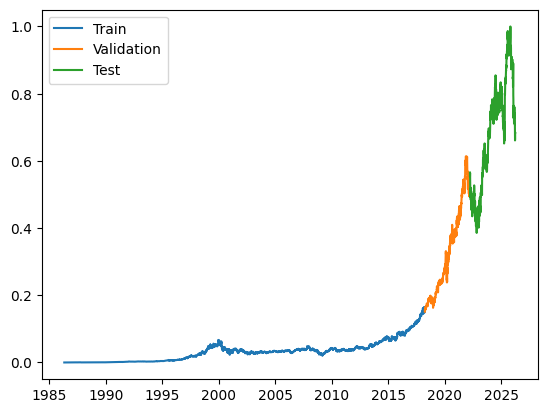

In [156]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
# 80% → Training
# 10% → Validation
# 10% → Testing

dates_train, X_train, y_train = dates[:q_80], X[:q_80,:,:], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [157]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

timesteps = 16
features = 5   # change depending on your features

inputs = layers.Input(shape=(timesteps, features))

# CNN
x = layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

# BiLSTM
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

# Attention
attention = layers.Attention()([x, x])
x = layers.GlobalAveragePooling1D()(attention)

# Dense layers
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape        ┃     Param # ┃ Connected to        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6         │ (None, 16, 5)       │           0 │ -                   │
│ (InputLayer)          │                     │             │                     │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ conv1d_6 (Conv1D)     │ (None, 16, 64)      │       1,024 │ input_layer_6[0][0] │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ max_pooling1d_6       │ (None, 8, 64)       │           0 │ conv1d_6[0][0]      │
│ (MaxPooling1D)        │                     │             │                     │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ bidirectional_6       │ (None, 8, 128)      │      66,048 │ max_pooling1d_6[0]… │
│ (Bidirectional)       │                     │             │                     │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ attention_6           │ (None, 8, 128)      │           0 │ bidirectional_6[0]… │
│ (Attention)           │                     │             │ bidirectional_6[0]… │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ global_average_pooli… │ (None, 128)         │           0 │ attention_6[0][0]   │
│ (GlobalAveragePoolin… │                     │             │                     │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ dense_12 (Dense)      │ (None, 32)          │       4,128 │ global_average_poo… │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ dropout_6 (Dropout)   │ (None, 32)          │           0 │ dense_12[0][0]      │
├───────────────────────┼─────────────────────┼─────────────┼─────────────────────┤
│ dense_13 (Dense)      │ (None, 1)           │          33 │ dropout_6[0][0]     │
└───────────────────────┴─────────────────────┴─────────────┴─────────────────────┘

 Total params: 71,233 (278.25 KB)

 Trainable params: 71,233 (278.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 2.6349e-04 - mae: 0.0092 - val_loss: 0.0051 - val_mae: 0.0589
Epoch 2/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5.0899e-05 - mae: 0.0044 - val_loss: 0.0029 - val_mae: 0.0431
Epoch 3/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.3285e-05 - mae: 0.0040 - val_loss: 0.0020 - val_mae: 0.0349
Epoch 4/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.5177e-05 - mae: 0.0038 - val_loss: 0.0018 - val_mae: 0.0331
Epoch 5/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.6613e-05 - mae: 0.0038 - val_loss: 0.0015 - val_mae: 0.0296
Epoch 6/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.2398e-05 - mae: 0.0037 - val_loss: 0.0019 - val_mae: 0.0355
Epoch 7/100
 16/252 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.4828e-05 - mae: 0.0041

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


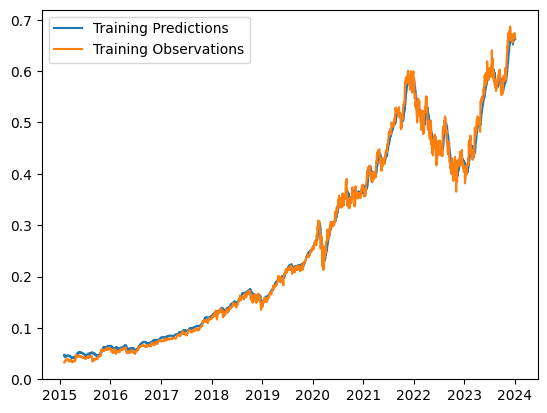

In [126]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


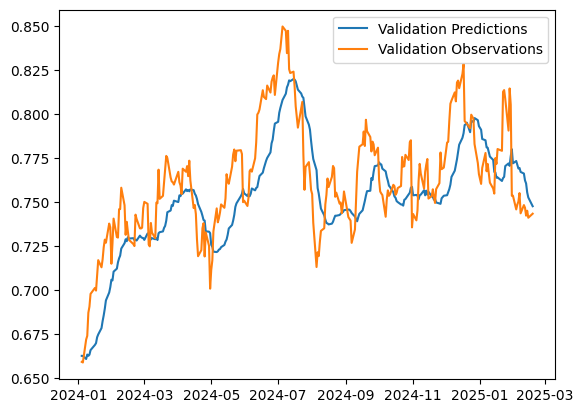

In [127]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


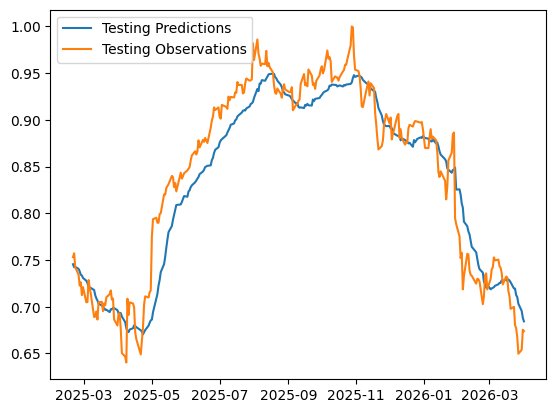

In [128]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [129]:
model.save("msft_cnn_bilstm_sentiment_model.keras")

In [ ]:
print("X scaler min:", X_scaler.data_min_)
print("X scaler max:", X_scaler.data_max_)
print("X scaler range:", X_scaler.data_range_)
print("X scaler scale:", X_scaler.scale_)
print("X scaler min offset:", X_scaler.min_)

In [ ]:
print("Y scaler min:", Y_scaler.data_min_)
print("Y scaler max:", Y_scaler.data_max_)
print("Y scaler range:", Y_scaler.data_range_)
print("Y scaler scale:", Y_scaler.scale_)
print("Y scaler min offset:", Y_scaler.min_)

In [133]:
import yfinance as yf
import numpy as np
import pandas as pd
import joblib
from tensorflow import keras

model = keras.models.load_model("E:/3rd_sem_project/stock_price_predictor_models/v1/msft_cnn_bilstm_sentiment_model.keras")

X_scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/X_scaler.pkl")
Y_scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/Y_scaler.pkl")

ticker = "MSFT"

data = yf.download(ticker, period="40d")

data = data.dropna()

cols = ["Open","High","Low","Close","Volume"]

window_size = 16

prices = data[cols].tail(window_size).values

scaled = X_scaler.transform(prices)

X_input = scaled.reshape(1, window_size, len(cols))

pred_scaled = model.predict(X_input)

pred_price = Y_scaler.inverse_transform(pred_scaled)

print("Predicted next close price:", pred_price[0][0])

[*********************100%***********************]  1 of 1 completed
E:\3rd_sem_project\stock_price_predictor_models\v1\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Predicted next close price: 381.2004
